# ISL Hand Sign Keypoint Classifier
This notebook trains a neural network to classify Indian Sign Language (ISL) hand signs (A-Z) using MediaPipe hand landmarks.

In [1]:
import csv
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

## 1. File Paths

In [2]:
#dataset        = 'model/keypoint_classifier/keypoint.csv'
dataset = "model/keypoint_classifier/keypoint.csv" # For both hands
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

## 2. Class Count

**KEY CHANGE:** Set this to the number of signs you have collected.

- For A-Z (26 letters, single-hand only): `NUM_CLASSES = 26`
- If you also have two-hand signs mixed in: keep the same count but make sure your CSV has the right feature length (see note below).

> **IMPORTANT — Input size note:**
> - Single-hand signs → 21 landmarks × 2 coords = **42 features** per row in the CSV
> - Two-hand signs → 42 landmarks × 2 coords = **84 features** per row in the CSV
>
> You must train **two separate models** if you mix single-hand and two-hand signs, OR pad
> single-hand rows with zeros to always have 84 features and use one model.
> The cell below uses `NUM_FEATURES` so you only have to change it in one place.

In [3]:
NUM_CLASSES = 26         # A-Z = 26. Change if you add more signs later.

# Always use 84 features regardless of one or two hands.
# Single-hand signs (like C) → 42 real features + 42 zeros (padding)
# Two-hand signs (like A)    → 42 features (left) + 42 features (right)
NUM_FEATURES = 42 * 2   # = 84

## 3. Load Training Data

In [4]:
# Column 0 = class label, columns 1..NUM_FEATURES = landmark coordinates
X_dataset = np.loadtxt(
    dataset,
    delimiter=',',
    dtype='float32',
    usecols=list(range(1, NUM_FEATURES + 1))
)

y_dataset = np.loadtxt(
    dataset,
    delimiter=',',
    dtype='int32',
    usecols=(0)
)

print(f'Dataset shape: X={X_dataset.shape}, y={y_dataset.shape}')
print(f'Classes found: {sorted(set(y_dataset.tolist()))}')

Dataset shape: X=(500, 84), y=(500,)
Classes found: [2, 11, 14, 20, 21]


In [5]:
# Split: 75% training, 25% validation
X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, y_dataset,
    train_size=0.75,
    random_state=RANDOM_SEED
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 375 samples | Test: 125 samples


## 4. Build the Model

**KEY CHANGES from original:**
- `Input` layer now uses `NUM_FEATURES` (42 for single-hand, 84 for two-hand)
- Hidden layers are wider (128 → 64) to handle 26 classes instead of 3
- Output layer uses `NUM_CLASSES` (26) instead of hardcoded 3

In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((NUM_FEATURES,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 84)                0         
                                                                 
 dense (Dense)               (None, 128)               10880     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 26)                1690      
                                                                 
Total params: 20826 (81.35 KB)
Trainable params: 20826 (

## 5. Callbacks

In [7]:
# Save best model checkpoint
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path,
    verbose=1,
    save_weights_only=False
)

# Stop early if validation loss stops improving
es_callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    verbose=1,
    restore_best_weights=True   # <-- added: revert to best epoch on stop
)

## 6. Compile

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Train

In [9]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
1/3 [=========>....................] - ETA: 1s - loss: 3.4847 - accuracy: 0.0078
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5


f:\Projects\NeuroSign\backend\venv_train\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3/3 [==============================] - 2s 363ms/step - loss: 3.4059 - accuracy: 0.0400 - val_loss: 3.1492 - val_accuracy: 0.2400
Epoch 2/1000
1/3 [=========>....................] - ETA: 0s - loss: 3.2379 - accuracy: 0.0703
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
3/3 [==============================] - 0s 84ms/step - loss: 3.1942 - accuracy: 0.0933 - val_loss: 2.9778 - val_accuracy: 0.2640
Epoch 3/1000
1/3 [=========>....................] - ETA: 0s - loss: 3.0481 - accuracy: 0.1094
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
3/3 [==============================] - 0s 62ms/step - loss: 3.0011 - accuracy: 0.1280 - val_loss: 2.8103 - val_accuracy: 0.3280
Epoch 4/1000
1/3 [=========>....................] - ETA: 0s - loss: 2.8386 - accuracy: 0.1719
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
3/3 [==============================] - 0s 66ms/step - loss: 2.7713 - accuracy: 0.2320 - val_loss: 2.6372 

## 8. Evaluate

In [10]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)
print(f'Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

1/1 [==============================] - 0s 39ms/step - loss: 0.0203 - accuracy: 1.0000
Validation loss: 0.0203 | Validation accuracy: 1.0000


## 9. Reload Saved Model & Quick Inference Test

In [11]:
# Load the best saved model
model = tf.keras.models.load_model(model_save_path)

# Run inference on one test sample
predict_result = model.predict(np.array([X_test[0]]))
print('Class probabilities:', np.squeeze(predict_result))
print('Predicted class index:', np.argmax(np.squeeze(predict_result)))
print('True class index:     ', y_test[0])

1/1 [==============================] - 0s 105ms/step
Class probabilities: [5.4280576e-06 5.3903173e-06 2.3091058e-04 1.9952547e-06 6.6419816e-06
 7.5875578e-06 5.4203242e-06 9.6896438e-06 5.9738140e-06 4.2784345e-06
 7.3608494e-06 9.9791342e-01 5.4193424e-06 1.0226908e-05 1.3091130e-03
 2.5708421e-06 1.0166335e-05 6.4246083e-06 7.0129154e-06 7.7730656e-06
 1.5788934e-05 3.8600311e-04 1.5998576e-05 5.9022464e-06 6.2857794e-06
 7.1920158e-06]
Predicted class index: 11
True class index:      11


## 10. Confusion Matrix & Classification Report

Matplotlib is building the font cache; this may take a moment.


4/4 [==============================] - 0s 2ms/step


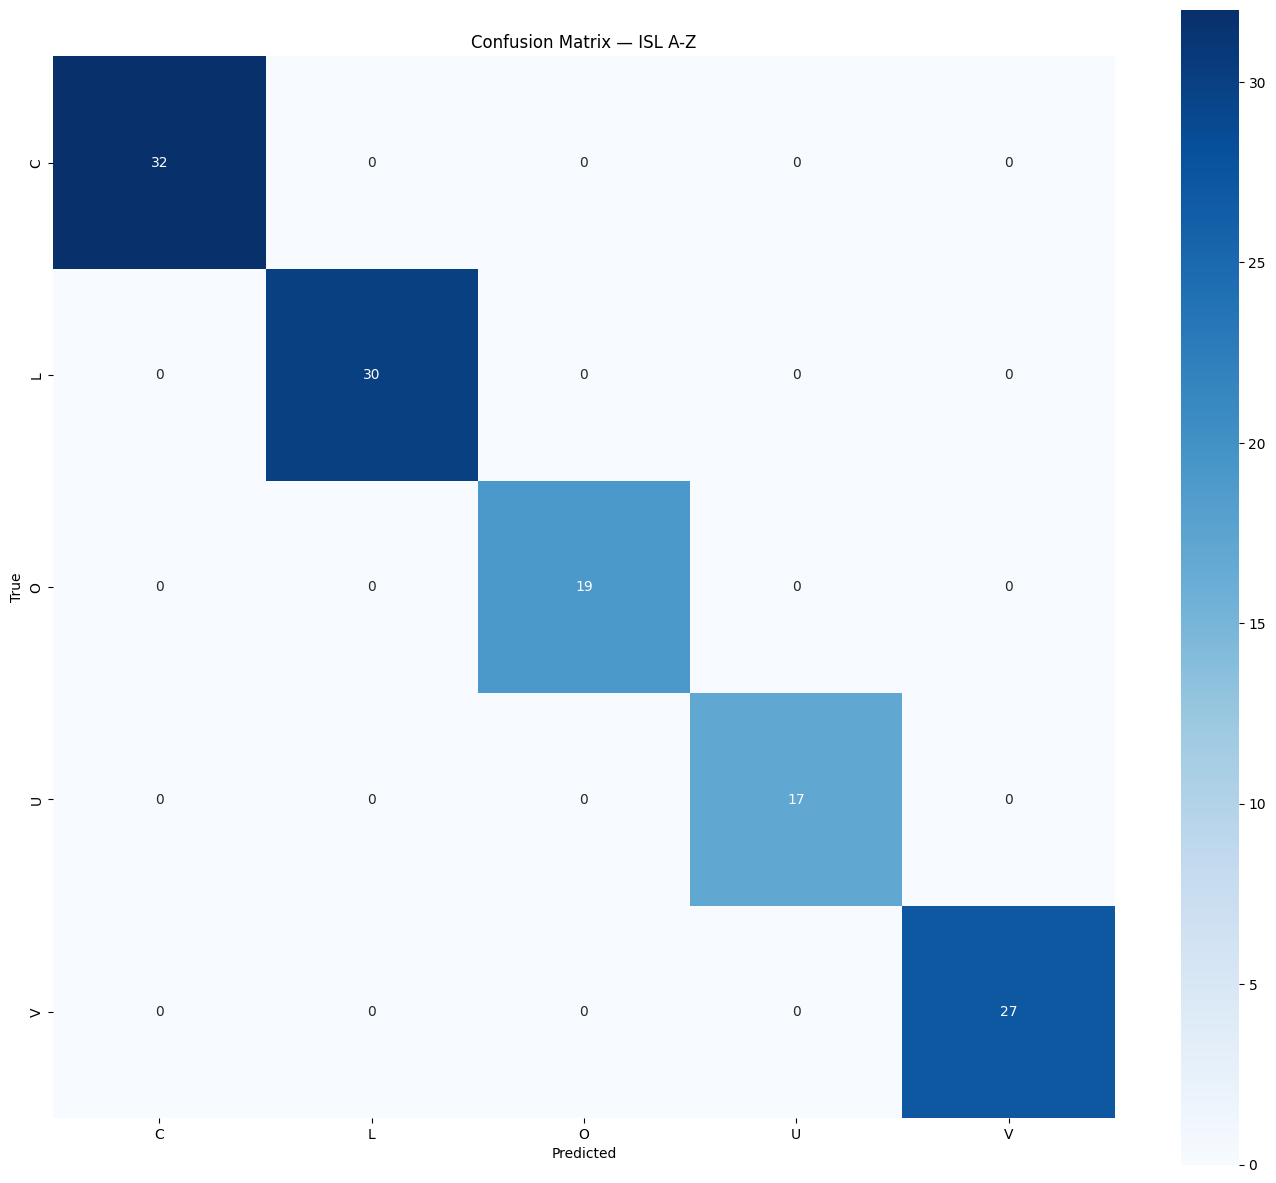

Classification Report
              precision    recall  f1-score   support

           C       1.00      1.00      1.00        32
           L       1.00      1.00      1.00        30
           O       1.00      1.00      1.00        19
           U       1.00      1.00      1.00        17
           V       1.00      1.00      1.00        27

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



In [12]:
import string
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Map class indices 0-25 to letters A-Z for readable labels
ALPHABET = list(string.ascii_uppercase)  # ['A', 'B', ..., 'Z']

def print_confusion_matrix(y_true, y_pred, class_names, report=True):
    labels = sorted(list(set(y_true)))
    label_names = [class_names[i] for i in labels]

    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    df_cmx = pd.DataFrame(cmx_data, index=label_names, columns=label_names)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(df_cmx, annot=True, fmt='g', square=True, cmap='Blues')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix — ISL A-Z')
    plt.tight_layout()
    plt.show()

    if report:
        print('Classification Report')
        print(classification_report(y_true, y_pred, target_names=label_names))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred, class_names=ALPHABET)

## 11. Convert to TensorFlow Lite (for use in app.py)

In [13]:
# Save inference-only model (no optimizer state)
model.save(model_save_path, include_optimizer=False)

f:\Projects\NeuroSign\backend\venv_train\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
# Convert to quantized TFLite model (smaller & faster on CPU/edge devices)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)
print(f'TFLite model saved to: {tflite_save_path}')

INFO:tensorflow:Assets written to: C:\Users\admin\AppData\Local\Temp\tmphyb26r_t\assets


INFO:tensorflow:Assets written to: C:\Users\admin\AppData\Local\Temp\tmphyb26r_t\assets


TFLite model saved to: model/keypoint_classifier/keypoint_classifier.tflite


## 12. TFLite Inference Test

In [15]:
# Load TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

# Get input/output tensor info
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input shape expected by TFLite model:', input_details[0]['shape'])
# Should print: [1, 42] for single-hand or [1, 84] for two-hand

Input shape expected by TFLite model: [ 1 84]


In [16]:
%%time
# Run TFLite inference on one test sample
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

print('TFLite class probabilities:', np.squeeze(tflite_results))
print('TFLite predicted class:    ', np.argmax(np.squeeze(tflite_results)))
print('Keras  predicted class:    ', np.argmax(model.predict(np.array([X_test[0]]))))
print('True class:                ', y_test[0])

TFLite class probabilities: [5.3955755e-06 5.2697528e-06 2.3224260e-04 2.0485779e-06 6.5897980e-06
 7.5183189e-06 5.3000740e-06 9.7714028e-06 5.9363051e-06 4.3041196e-06
 7.3085935e-06 9.9791855e-01 5.5534133e-06 1.0271768e-05 1.3030283e-03
 2.5483348e-06 1.0282745e-05 6.3912985e-06 6.9818939e-06 7.5770035e-06
 1.5259795e-05 3.8642940e-04 1.6014503e-05 5.8329292e-06 6.3889279e-06
 7.1844161e-06]
TFLite predicted class:     11
1/1 [==============================] - 0s 17ms/step
Keras  predicted class:     11
True class:                 11
CPU times: total: 93.8 ms
Wall time: 58.5 ms
